In [82]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor


In [83]:
sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)


In [84]:
df = pd.read_excel("Copy of Product1_masterData.xlsx")
df.head()

,Seed Preparation,Bioreactor,Glucose Addition,Culture Phase,Batch No,EFT (h),Res Glc (g/L),Lactate (g/L),Titer (mg/L),Productivity (g/D),Perfusion (LPD),Capacitance (pf/cm),Agitation SP (RPM),DO SP (%),Temp SP (Deg C),Alkali (LPD),Feed C (LPD)
0,Cell Stack,NBS,No,Growth,1510,0.0,5.17,0.13,NaN,NaN,NaN,NaN,150.0,30.0,36.5,NaN,NaN
1,Cell Stack,NBS,No,Growth,1510,24.0,3.96,1.51,NaN,NaN,NaN,NaN,150.0,30.0,36.5,NaN,NaN
2,Cell Stack,NBS,No,Growth,1510,48.0,2.39,3.43,NaN,NaN,NaN,NaN,150.0,30.0,36.5,NaN,NaN
3,Cell Stack,NBS,No,Growth,1510,52.0,1.87,3.88,NaN,NaN,NaN,NaN,150.0,30.0,36.5,NaN,NaN
4,Cell Stack,NBS,No,Growth,1510,56.0,1.52,4.32,NaN,NaN,NaN,NaN,150.0,30.0,36.5,NaN,NaN


In [85]:
df.shape

(31732, 17)

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31732 entries, 0 to 31731
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Seed Preparation     31732 non-null  object 
 1   Bioreactor           31732 non-null  object 
 2   Glucose Addition     31732 non-null  object 
 3   Culture Phase        31732 non-null  object 
 4   Batch No             31732 non-null  int64  
 5   EFT (h)              31732 non-null  float64
 6   Res Glc (g/L)        31629 non-null  object 
 7   Lactate (g/L)        31629 non-null  float64
 8   Titer (mg/L)         5271 non-null   float64
 9   Productivity (g/D)   5270 non-null   float64
 10  Perfusion (LPD)      30495 non-null  float64
 11  Capacitance (pf/cm)  9730 non-null   object 
 12  Agitation SP (RPM)   31728 non-null  float64
 13  DO SP  (%)           31726 non-null  float64
 14  Temp SP (Deg C)      31728 non-null  float64
 15  Alkali (LPD)         5827 non-null  

In [88]:
# fixing the datatypes
num_like_cols = [
    'Res Glc (g/L)',
    'Capacitance (pf/cm)',
    'Alkali (LPD)'
]

for col in num_like_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


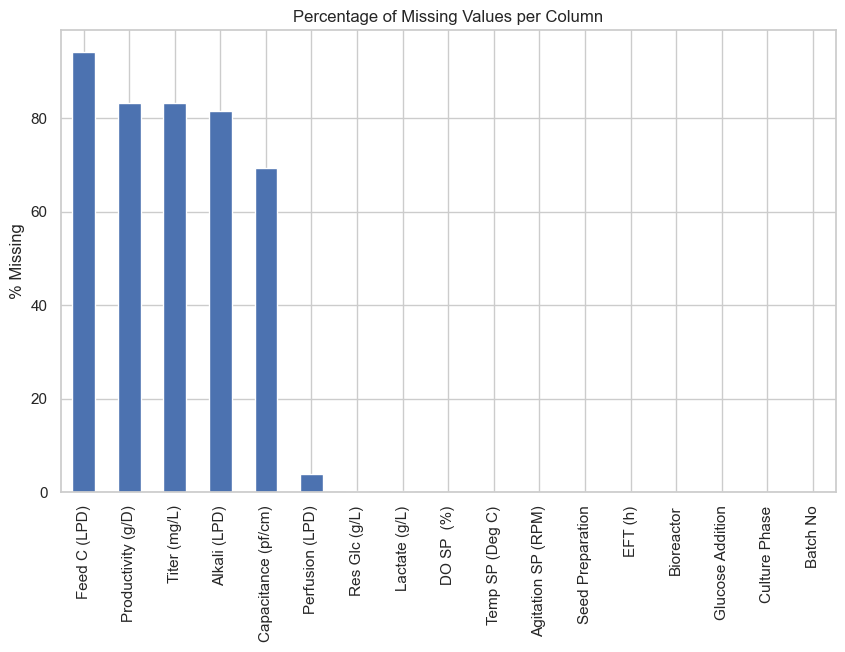

In [90]:
missing_values = (df.isnull().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(10,6))
missing_values.plot(kind='bar')
plt.ylabel("% Missing")
plt.title("Percentage of Missing Values per Column")
plt.show()


In [91]:
df.isnull().sum()
df.isna().mean().sort_values(ascending=False)

Feed C (LPD)           0.941447
Productivity (g/D)     0.833922
Titer (mg/L)           0.833890
Alkali (LPD)           0.816400
Capacitance (pf/cm)    0.693401
Perfusion (LPD)        0.038983
Res Glc (g/L)          0.003309
Lactate (g/L)          0.003246
DO SP  (%)             0.000189
Temp SP (Deg C)        0.000126
Agitation SP (RPM)     0.000126
Seed Preparation       0.000000
EFT (h)                0.000000
Bioreactor             0.000000
Glucose Addition       0.000000
Culture Phase          0.000000
Batch No               0.000000
dtype: float64

In [92]:
df.groupby("Culture Phase").apply(lambda x: x.isnull().mean()*100)

,Seed Preparation,Bioreactor,Glucose Addition,Culture Phase,Batch No,EFT (h),Res Glc (g/L),Lactate (g/L),Titer (mg/L),Productivity (g/D),Perfusion (LPD),Capacitance (pf/cm),Agitation SP (RPM),DO SP (%),Temp SP (Deg C),Alkali (LPD),Feed C (LPD)
Culture Phase,,,,,,,,,,,,,,,,,
Growth,0.0,0.0,0.0,0.0,0.0,0.0,1.039034,1.039034,99.691098,99.691098,34.456613,69.755687,0.000000,0.000000,0.000000,87.896658,100.000000
Production,0.0,0.0,0.0,0.0,0.0,0.0,0.241383,0.234283,81.328316,81.331866,0.035497,69.287565,0.014199,0.021298,0.014199,80.849100,93.404565


In [93]:
df = df.sort_values(["Batch No", "EFT (h)"])
#These are the setpoint columns: temperature, dissolved oxygen (DO), and agitation speed.
#These values are usually constant or controlled during a batch but might be missing at some time points in the dataset.


sp_cols = ["Temp SP (Deg C)", "DO SP  (%)", "Agitation SP (RPM)"]

df[sp_cols] = (
    df.groupby("Batch No")[sp_cols]
      .ffill()
      .bfill()
)

In [94]:
#A missing flow often means no addition occurred at that time.
#Using 0 avoids errors in calculations or aggregations later.

flow_cols = ["Feed C (LPD)", "Alkali (LPD)", "Perfusion (LPD)"]
df[flow_cols] = df[flow_cols].fillna(0)


In [95]:
#Offline measurements are sparse (not measured every hour).Interpolating fills small gaps while keeping trends realistic.
#Using limit=1 ensures you don’t overfill missing data and introduce inaccurate values.
offline_cols = ["Lactate (g/L)",  "Res Glc (g/L)"]

df[offline_cols] = (
    df.groupby("Batch No")[offline_cols]
      .transform(lambda x: x.interpolate(limit=1, limit_direction="forward"))
)


In [96]:
df["Capacitance (pf/cm)"] = (
    df.groupby("Batch No")["Capacitance (pf/cm)"]
      .transform(lambda x: x.interpolate(limit=1).ffill())
)


In [97]:
df.isnull().sum()

Seed Preparation           0
Bioreactor                 0
Glucose Addition           0
Culture Phase              0
Batch No                   0
EFT (h)                    0
Res Glc (g/L)             31
Lactate (g/L)             31
Titer (mg/L)           26461
Productivity (g/D)     26462
Perfusion (LPD)            0
Capacitance (pf/cm)     5821
Agitation SP (RPM)         0
DO SP  (%)                 0
Temp SP (Deg C)            0
Alkali (LPD)               0
Feed C (LPD)               0
dtype: int64

In [98]:
df.describe()

,Batch No,EFT (h),Res Glc (g/L),Lactate (g/L),Titer (mg/L),Productivity (g/D),Perfusion (LPD),Capacitance (pf/cm),Agitation SP (RPM),DO SP (%),Temp SP (Deg C),Alkali (LPD),Feed C (LPD)
count,31732.000000,31732.000000,31701.000000,31701.000000,5271.000000,5270.000000,31732.000000,25911.000000,31732.000000,31732.000000,31732.000000,31732.000000,31732.000000
mean,1993.028678,655.909114,0.460267,3.622832,40.403035,5.948800,130.916709,148.970655,255.599363,56.246908,35.392490,0.876466,0.175555
std,324.767861,397.984432,0.819799,0.965714,17.923783,2.938765,82.457447,65.421491,60.261952,13.921741,1.105793,2.459385,0.723820
min,1510.000000,0.000000,0.000000,0.000000,7.610000,0.146700,0.000000,0.590000,150.000000,22.000000,31.500000,0.000000,0.000000
25%,1704.000000,334.000000,0.120000,3.040000,27.510000,3.689710,57.000000,101.500000,181.000000,48.000000,34.500000,0.000000,0.000000
50%,2002.000000,628.000000,0.200000,3.770000,35.910000,5.723110,132.000000,158.000000,285.000000,60.000000,35.500000,0.000000,0.000000
75%,2305.000000,935.000000,0.430000,4.310000,48.680000,7.927050,205.000000,200.000000,300.000000,69.000000,36.500000,0.000000,0.000000
max,2514.000000,2159.000000,29.000000,6.730000,119.900000,18.080000,316.000000,322.000000,360.000000,96.000000,36.500000,23.000000,3.900000


The dataset contains ~31,700 observations across multiple batches, covering extended culture durations (EFT up to ~2,500 h) and providing robust process representation.

Residual glucose remains low on average, indicating effective feed control, while lactate shows moderate variability reflecting shifts in cellular metabolic state.

Titer and productivity exhibit right-skewed distributions with occasional high values, corresponding to peak production phases rather than steady-state operation.

Perfusion rate and capacitance span wide ranges, capturing transitions from low to high biomass and intensified perfusion regimes; missing values are likely phase-dependent.

Agitation, dissolved oxygen, and temperature setpoints are tightly controlled, demonstrating stable and consistent operating conditions.

Alkali and feed C rates are zero for most observations, with intermittent spikes indicating responsive pH and nutrient control during periods of increased metabolic demand.

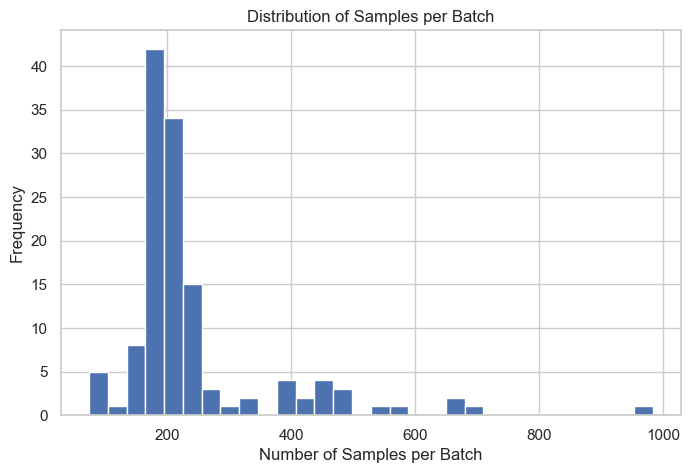

In [99]:
batch_counts = df['Batch No'].value_counts()

plt.figure(figsize=(8,5))
batch_counts.hist(bins=30)
plt.xlabel("Number of Samples per Batch")
plt.ylabel("Frequency")
plt.title("Distribution of Samples per Batch")
plt.show()


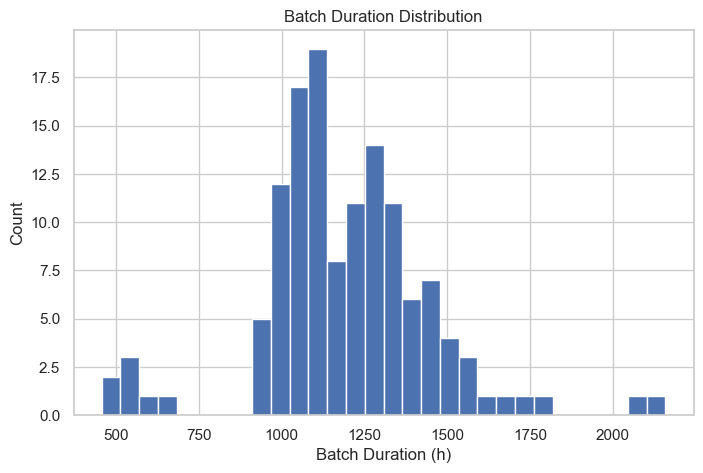

In [100]:
batch_duration = df.groupby('Batch No')['EFT (h)'].max()

plt.figure(figsize=(8,5))
batch_duration.hist(bins=30)
plt.xlabel("Batch Duration (h)")
plt.ylabel("Count")
plt.title("Batch Duration Distribution")
plt.show()


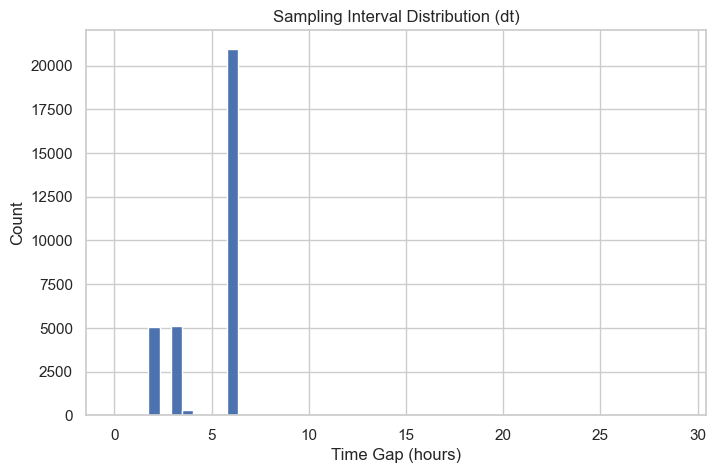

In [101]:
# Sampling interval
df = df.sort_values(['Batch No', 'EFT (h)'])

df['dt'] = df.groupby('Batch No')['EFT (h)'].diff()

plt.figure(figsize=(8,5))
df['dt'].dropna().hist(bins=50)
plt.xlabel("Time Gap (hours)")
plt.ylabel("Count")
plt.title("Sampling Interval Distribution (dt)")
plt.show()


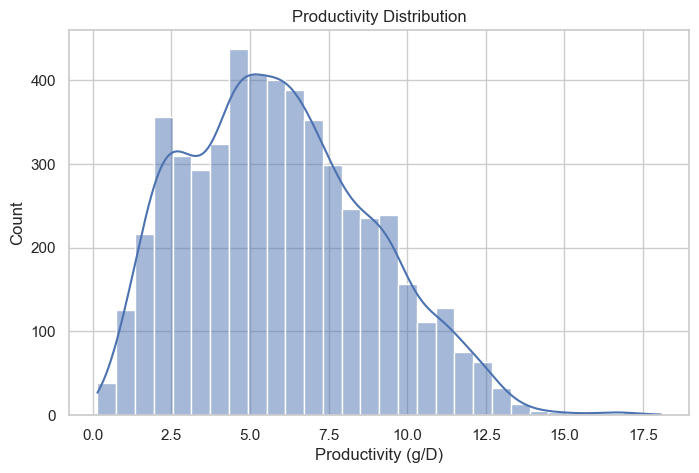

In [103]:
plt.figure(figsize=(8,5))
sns.histplot(df['Productivity (g/D)'], bins=30, kde=True)
plt.title("Productivity Distribution")
plt.show()


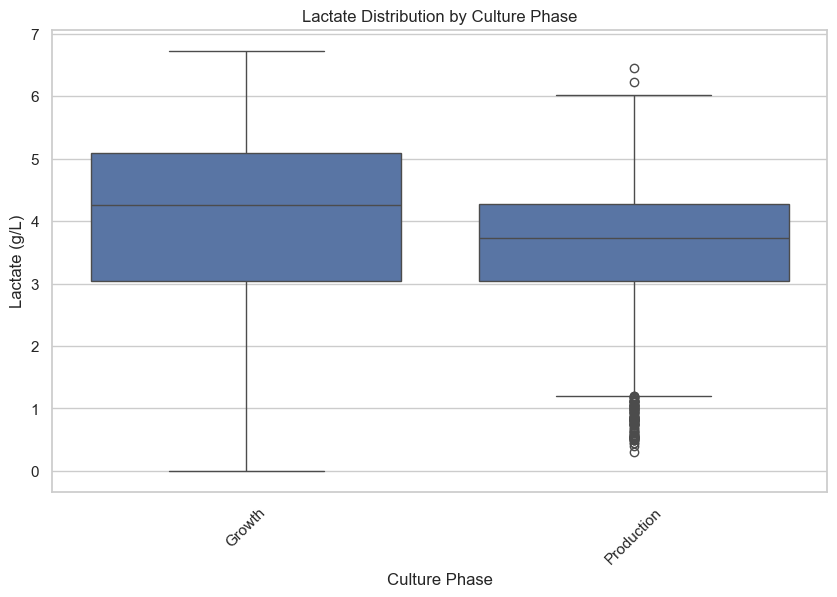

In [104]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='Culture Phase',
    y='Lactate (g/L)'
)
plt.xticks(rotation=45)
plt.title("Lactate Distribution by Culture Phase")
plt.show()


In [25]:
import warnings
warnings.filterwarnings("ignore")



In [26]:
# Defining process phase 

prod_df =df[df['Culture Phase']== 'Production']
growth_df = df [df['Culture Phase']== 'Growth']

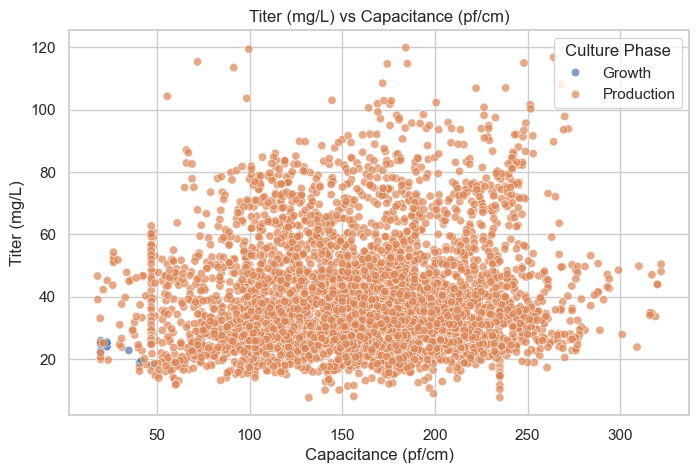

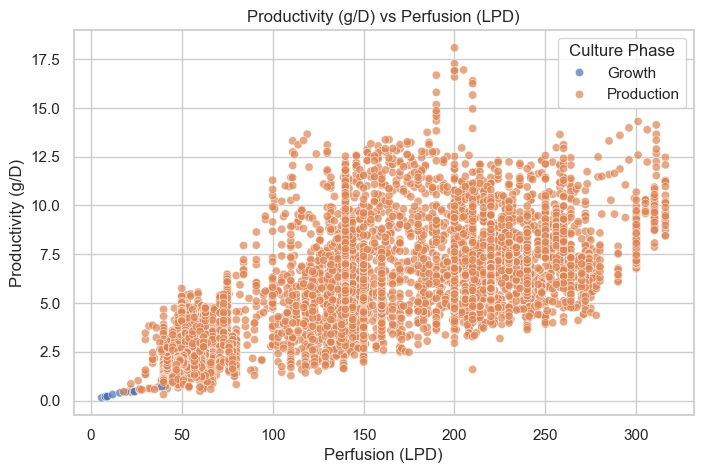

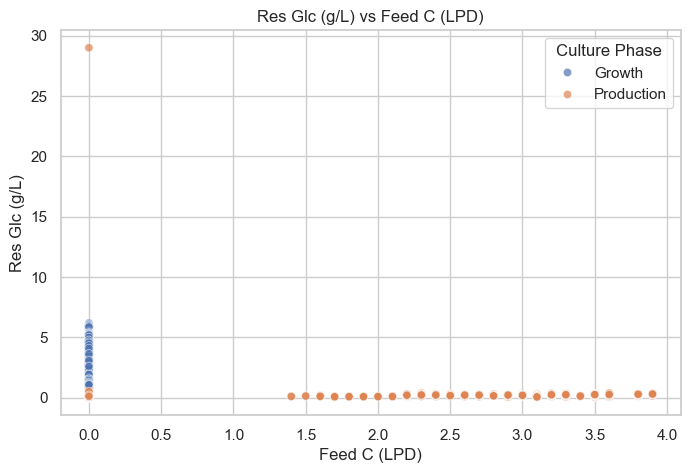

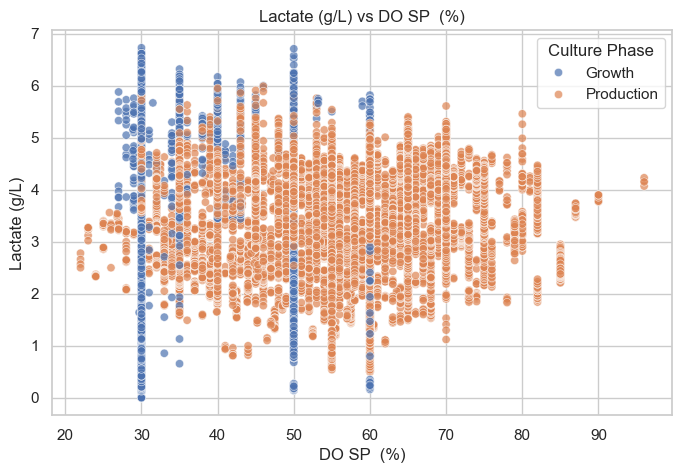

In [106]:
important_pairs = [

    ("Capacitance (pf/cm)", "Titer (mg/L)"),
    ("Perfusion (LPD)", "Productivity (g/D)"),
    ("Feed C (LPD)", "Res Glc (g/L)"),
    ("DO SP  (%)", "Lactate (g/L)")
]

for x, y in important_pairs:
    plt.figure()
    sns.scatterplot(
        data=df, x=x, y=y,
        hue="Culture Phase", alpha=0.7
    )
    plt.title(f"{y} vs {x}")
    plt.show()


## Random Forest algorithm

In [235]:
df['Batch No'] = df['Batch No'].astype(str).str.strip()

# Filter production phase
prod_df = df[(df['Culture Phase'] == 'Production') & (df['Titer (mg/L)'].notnull())].copy()

prod_df['Glucose Addition'] = (
    prod_df['Glucose Addition']
    .astype(str)
    .str.replace('g/L', '', regex=False)
    .replace('No', 0)
)
prod_df['Glucose Addition'] = pd.to_numeric(prod_df['Glucose Addition'], errors='coerce')

# Sortingt the values on batch no and eft
prod_df = prod_df.sort_values(['Batch No', 'EFT (h)'])
process_cols = [
    'Perfusion (LPD)', 'Agitation SP (RPM)', 'Lactate (g/L)', 
    'Capacitance (pf/cm)', 'DO SP  (%)', 'Res Glc (g/L)', 
    'Temp SP (Deg C)', 'Alkali (LPD)', 'Glucose Addition'
]

prod_df[process_cols] = (
    prod_df
    .groupby('Batch No')[process_cols]
    .transform(lambda x: x.interpolate(method='linear'))
)

prod_df = prod_df.dropna(subset=process_cols)


               Feature  Importance
2        Lactate (g/L)    0.583364
9              EFT (h)    0.181920
5        Res Glc (g/L)    0.045290
3  Capacitance (pf/cm)    0.042039
0      Perfusion (LPD)    0.037640
4           DO SP  (%)    0.031495
1   Agitation SP (RPM)    0.029370
7         Alkali (LPD)    0.027590
6      Temp SP (Deg C)    0.017998
8     Glucose Addition    0.003294


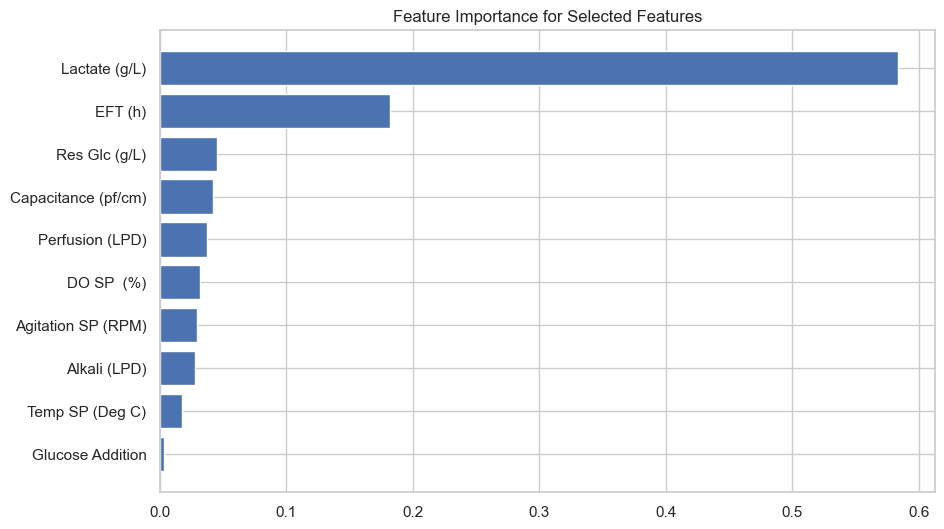

In [236]:

target = 'Titer (mg/L)'
feature_cols = process_cols + ['EFT (h)']
#defining x , y  
X = prod_df[feature_cols]
y = prod_df[target]

# Using groupsplit which will split the data on batch number 
from sklearn.model_selection import GroupShuffleSplit
# Using 20 percent data to test and 80 percent to train 
gss = GroupShuffleSplit(test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=prod_df['Batch No']))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
model.fit(X_train, y_train)

# Cheking the feature importance
feat_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(feat_importance)

#  Plotting feature importance 
plt.figure(figsize=(10,6))
plt.barh(feat_importance['Feature'], feat_importance['Importance'])
plt.gca().invert_yaxis()
plt.title('Feature Importance for Selected Features')
plt.show()

<Axes: xlabel='Glucose Addition', ylabel='Titer (mg/L)'>

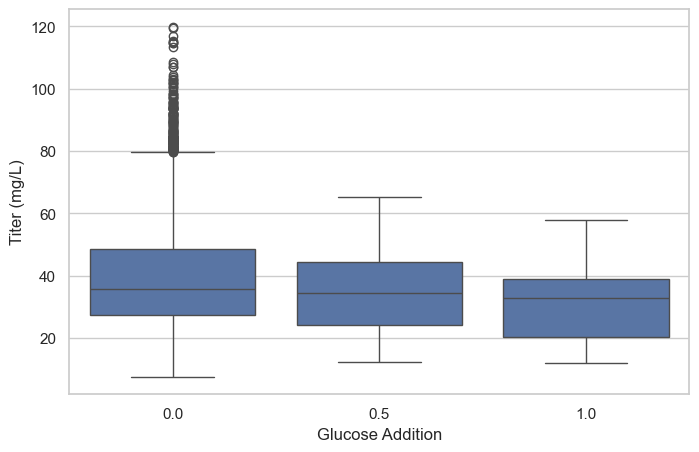

In [237]:
import seaborn as sns
#Plotting a graph to check the effect of glucose addition on Titer
sns.boxplot(x='Glucose Addition', y='Titer (mg/L)', data=prod_df)

In [238]:
from sklearn.metrics import r2_score, mean_squared_error
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)

print("R2 Score:", r2)
print("RMSE:", rmse)

R2 Score: 0.7470911486590428
RMSE: 91.37746608257561


In [239]:
train_batches = prod_df.iloc[train_idx]['Batch No'].unique()
test_batches = prod_df.iloc[test_idx]['Batch No'].unique()

print("Training Batches:", train_batches)
print("Testing Batches:", test_batches)

Training Batches: ['1601' '1602' '1603' '1605' '1606' '1607' '1608' '1609' '1704' '1705'
 '1706' '1707' '1708' '1801' '1802' '1803' '1804' '1805' '1806' '1807'
 '1808' '1810' '1811' '1812' '1903' '1904' '1905' '1906' '1908' '2001'
 '2002' '2003' '2006' '2008' '2013' '2014' '2101' '2103' '2104' '2106'
 '2109' '2111' '2112' '2201' '2202' '2203' '2206' '2208' '2209' '2210'
 '2211' '2212' '2213' '2301' '2302' '2303' '2306' '2309' '2311' '2401'
 '2402' '2404' '2405' '2410' '2411' '2413' '2414' '2415' '2416' '2417'
 '2418' '2419' '2420' '2421' '2422' '2501' '2503' '2504' '2505' '2506'
 '2507' '2508' '2509' '2510' '2511' '2512' '2514']
Testing Batches: ['1512' '1604' '1701' '1702' '1703' '1709' '1902' '1910' '2010' '2015'
 '2205' '2214' '2305' '2307' '2310' '2406' '2407' '2408' '2409' '2412'
 '2502' '2513']


In [240]:
batch = '2513'
batch_result = results[results['Batch No'] == batch].sort_values('EFT (h)')
print(batch_result)

    Batch No  EFT (h)  Actual_Titer  Predicted_Titer
847     2513    186.0         33.29        32.243033
848     2513    210.0         22.67        25.783733
849     2513    234.0         23.63        26.940300
850     2513    258.0         24.55        29.762167
851     2513    282.0         27.72        29.964000
852     2513    306.0         28.96        32.581300
853     2513    330.0         29.40        33.602567
854     2513    354.0         31.80        36.535733
855     2513    378.0         33.64        38.769200
856     2513    402.0         37.38        42.363733
857     2513    426.0         40.28        42.518267
858     2513    450.0         44.35        42.954467
859     2513    474.0         43.51        43.280267
860     2513    498.0         47.44        44.340833
861     2513    522.0         47.43        46.056300
862     2513    546.0         49.50        48.258300
863     2513    570.0         47.53        48.148033
864     2513    594.0         46.89        46.

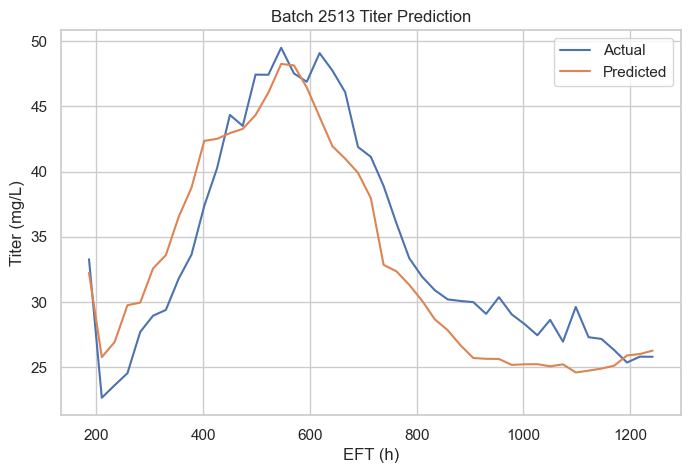

In [241]:

# plot showing actual vs predicted titer pattern
plt.plot(batch_result['EFT (h)'], batch_result['Actual_Titer'], label='Actual')
plt.plot(batch_result['EFT (h)'], batch_result['Predicted_Titer'], label='Predicted')

plt.xlabel('EFT (h)')
plt.ylabel('Titer (mg/L)')
plt.title(f'Batch {batch} Titer Prediction')
plt.legend()
plt.show()

## Again training the model with lag feature to see if there will be any improvment

In [242]:
# creating lag columns (shifting a dataset’s values backward)
lag_cols = [
    'Lactate (g/L)',
    'Res Glc (g/L)',
    'Capacitance (pf/cm)',
    'Perfusion (LPD)'
]

for col in lag_cols:
    prod_df[col + '_lag1'] = prod_df.groupby('Batch No')[col].shift(1)
for col in lag_cols:
    prod_df[col + '_lag2'] = prod_df.groupby('Batch No')[col].shift(2)

In [243]:
feature_cols = [
    'Perfusion (LPD)',
    'Agitation SP (RPM)',
    'Lactate (g/L)',
    'Capacitance (pf/cm)',
    'DO SP  (%)',
    'Res Glc (g/L)',
    'Temp SP (Deg C)',
    'Alkali (LPD)',
    'Glucose Addition',
    'EFT (h)',

    'Lactate (g/L)_lag1',
    'Res Glc (g/L)_lag1',
    'Capacitance (pf/cm)_lag1',
    'Perfusion (LPD)_lag1'
]

In [244]:
X = prod_df[feature_cols]
y = prod_df['Titer (mg/L)']

gss = GroupShuffleSplit(test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=prod_df['Batch No']))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.7560446846972655
RMSE: 88.14250047613731


In [245]:
results = pd.DataFrame({
    'Actual_Titer': y_test,
    'Predicted_Titer': y_pred
})

print(results.head(20))

      Actual_Titer  Predicted_Titer
1474         19.37        29.107533
1483         18.11        27.529167
1489         19.98        25.240833
1495         24.39        27.459967
1500         26.60        30.466433
1506         33.59        34.000500
1510         36.79        37.096100
1519         46.75        41.453700
1531         64.40        53.952300
1542         71.10        59.212100
1555         86.60        64.995300
1567         95.70        69.545300
1579         94.00        70.422333
1591         95.00        70.625767
1603         93.60        73.618067
1615         95.90        74.624100
1626         94.00        73.410833
1638         93.60        75.165733
1650         88.80        74.611367
1663         83.30        70.519233


In [246]:
train_batches = prod_df.iloc[train_idx]['Batch No'].unique()
test_batches = prod_df.iloc[test_idx]['Batch No'].unique()

print("Training Batches:", train_batches)
print("Testing Batches:", test_batches)

Training Batches: ['1601' '1602' '1603' '1605' '1606' '1607' '1608' '1609' '1704' '1705'
 '1706' '1707' '1708' '1801' '1802' '1803' '1804' '1805' '1806' '1807'
 '1808' '1810' '1811' '1812' '1903' '1904' '1905' '1906' '1908' '2001'
 '2002' '2003' '2006' '2008' '2013' '2014' '2101' '2103' '2104' '2106'
 '2109' '2111' '2112' '2201' '2202' '2203' '2206' '2208' '2209' '2210'
 '2211' '2212' '2213' '2301' '2302' '2303' '2306' '2309' '2311' '2401'
 '2402' '2404' '2405' '2410' '2411' '2413' '2414' '2415' '2416' '2417'
 '2418' '2419' '2420' '2421' '2422' '2501' '2503' '2504' '2505' '2506'
 '2507' '2508' '2509' '2510' '2511' '2512' '2514']
Testing Batches: ['1512' '1604' '1701' '1702' '1703' '1709' '1902' '1910' '2010' '2015'
 '2205' '2214' '2305' '2307' '2310' '2406' '2407' '2408' '2409' '2412'
 '2502' '2513']


In [247]:
results = pd.DataFrame({
    'Batch No': prod_df.iloc[test_idx]['Batch No'].values,
    'EFT (h)': prod_df.iloc[test_idx]['EFT (h)'].values,
    'Actual_Titer': y_test.values,
    'Predicted_Titer': y_pred
})

In [248]:
batch = '2513'
batch_result = results[results['Batch No'] == batch].sort_values('EFT (h)')
print(batch_result)

    Batch No  EFT (h)  Actual_Titer  Predicted_Titer
847     2513    186.0         33.29        32.243033
848     2513    210.0         22.67        25.783733
849     2513    234.0         23.63        26.940300
850     2513    258.0         24.55        29.762167
851     2513    282.0         27.72        29.964000
852     2513    306.0         28.96        32.581300
853     2513    330.0         29.40        33.602567
854     2513    354.0         31.80        36.535733
855     2513    378.0         33.64        38.769200
856     2513    402.0         37.38        42.363733
857     2513    426.0         40.28        42.518267
858     2513    450.0         44.35        42.954467
859     2513    474.0         43.51        43.280267
860     2513    498.0         47.44        44.340833
861     2513    522.0         47.43        46.056300
862     2513    546.0         49.50        48.258300
863     2513    570.0         47.53        48.148033
864     2513    594.0         46.89        46.

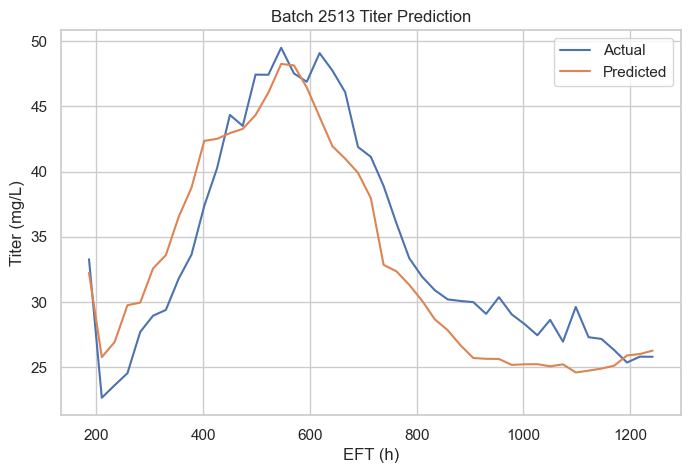

In [249]:

plt.plot(batch_result['EFT (h)'], batch_result['Actual_Titer'], label='Actual')
plt.plot(batch_result['EFT (h)'], batch_result['Predicted_Titer'], label='Predicted')

plt.xlabel('EFT (h)')
plt.ylabel('Titer (mg/L)')
plt.title(f'Batch {batch} Titer Prediction')
plt.legend()
plt.show()

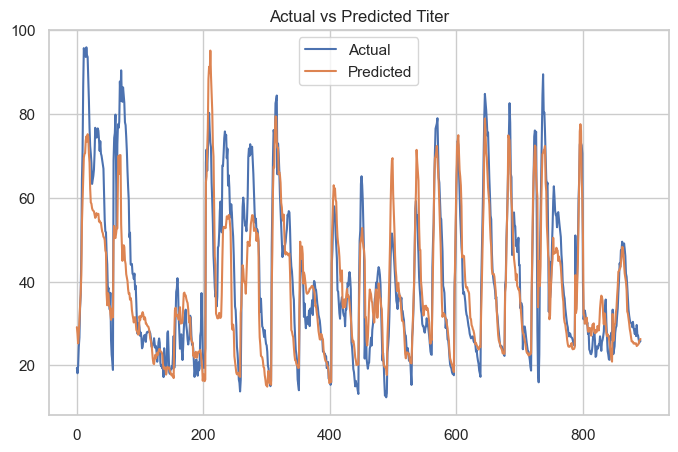

In [250]:
# Overall test batches titer pattern actual vs predicted
plt.figure(figsize=(8,5))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Titer")
plt.show()

In [251]:
# Manual predictio( just fill the values of variables below to get titer at that time point)

input_values = {
    'Perfusion (LPD)':212 ,
    'Agitation SP (RPM)':285 ,
    'Lactate (g/L)':4.02 ,
    'Capacitance (pf/cm)':213 ,
    'DO SP  (%)': 70,
    'Res Glc (g/L)':0.1 ,
    'Temp SP (Deg C)':35.5 ,
    'Alkali (LPD)': 8.4,
    'Glucose Addition':0 ,
    'EFT (h)':595 ,

    'Lactate (g/L)_lag1': 4.07,
    'Res Glc (g/L)_lag1':0.1 ,
    'Capacitance (pf/cm)_lag1':213 ,
    'Perfusion (LPD)_lag1': 212
}

# Converting in to dataframe
new_sample = pd.DataFrame([input_values])[feature_cols]

# Prediction 
predicted_titer = model.predict(new_sample)

print("Predicted Titer (mg/L):", predicted_titer[0])

Predicted Titer (mg/L): 44.50983333333329
